In [1]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix, plot_contrast_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img, get_data
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask
from pandas import read_excel

from nilearn.glm.second_level import SecondLevelModel
from scipy.stats import norm

from nilearn.glm import threshold_stats_img
from pathlib import Path
from atlasreader import create_output
from scipy.ndimage import label

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

virtueORvice = 'virtues' # vices, virtues

stories = ["tunnel","21styear"]

if whichVersion == "persentence":
    # output directory
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
    )
elif whichVersion == "3sec":
    # output directory
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation_3sec/"
    )
elif whichVersion == "6sec":
    # output directory
    base_dir1 = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation_6sec/"
    )

output_dir = Path(f"{base_dir1}{virtueORvice}/fcontrast/")


In [3]:
# Collect z-maps
z_maps = []
for story in stories:
    z_map_path = os.path.join(output_dir, story, "zscores_fcontrast_secondlevel.nii.gz")
    if os.path.exists(z_map_path):
        print(f"✅ Loaded {z_map_path}")
        z_maps.append(image.load_img(z_map_path))
    else:
        print(f"⚠️ Missing: {z_map_path}")

if len(z_maps) < 2:
    raise ValueError("Need at least two z-maps to compute a minimum-statistic conjunction.")

print(z_maps)

# Resample all to the first image’s space
target_img = z_maps[0]
z_maps_resampled = [image.resample_to_img(img, target_img, interpolation="continuous") for img in z_maps]

# Create dictionary dynamically
img_dict = {f"img{i+1}": z_maps_resampled[i] for i in range(len(z_maps_resampled))}
expr = "np.minimum.reduce((" + ", ".join(img_dict.keys()) + "))"

# Compute conjunction map
min_stat_map = image.math_img(expr, **img_dict)

# Save output
output_path = os.path.join(output_dir, "minimum_stat_conjunction.nii.gz")
min_stat_map.to_filename(output_path)
print(f"✅ Saved conjunction map to: {output_path}")

✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/tunnel/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/21styear/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/shapessocial/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives

/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_3449/1135267189.py:18: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  z_maps_resampled = [image.resample_to_img(img, target_img, interpolation="continuous") for img in z_maps]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_3449/1135267189.py:18: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  z_maps_resampled = [image.resample_to_img(img, target_img, interpolation="continuou

✅ Saved conjunction map to: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/minimum_stat_conjunction.nii.gz


In [4]:

thresholded_map, threshold = threshold_stats_img(
    stat_img=min_stat_map,
    alpha=0.05,            # FDR level (start here)
    height_control='fdr',  # use 'bonferroni' for more conservative FWER control
    cluster_threshold=0,   # use >0 to filter small clusters
    two_sided=True        # or True if you want two-sided test
)

print(threshold)

output_path = os.path.join(output_dir, "min_stat_conjunction_fdrcorrected.nii.gz")
thresholded_map.to_filename(output_path)

3.9159688970347886


In [5]:

# Display the thresholded statistical map on a glass brain
display = plotting.plot_glass_brain(
    thresholded_map,
    threshold=None,         
    colorbar=True,
    display_mode='lyrz',     # Combine lateral, coronal, sagittal, axial views
    plot_abs=False,          # Set True if you want both positive & negative activations
    cmap='cold_hot',         # Common for statistical maps
    title='FDR-corrected',
)

# Save the glass brain figure as an image
fig_path = os.path.join(output_dir, "glassbrain_min_stat_conjunction_fdrcorrected.png")
display.savefig(fig_path, dpi=300)
display.close()

print(f"Glass brain saved at: {fig_path}")


Glass brain saved at: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/glassbrain_min_stat_conjunction_fdrcorrected.png


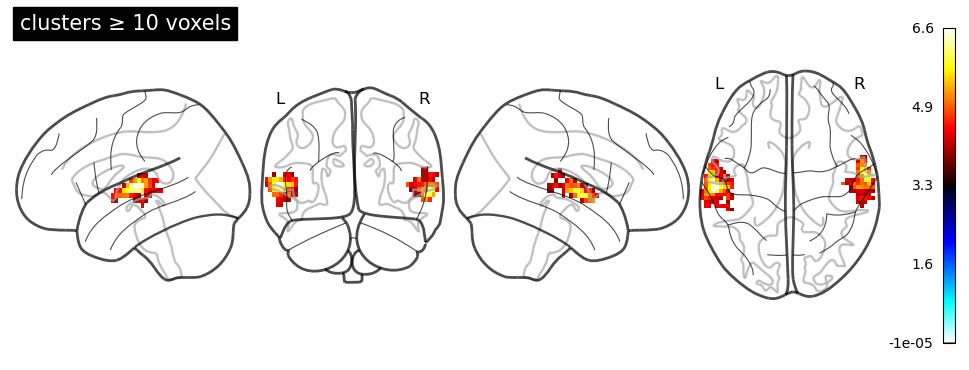

In [6]:
# glass brain 10+ voxels
load_fdr_image = os.path.join(output_dir, "min_stat_conjunction_fdrcorrected.nii.gz")
stat_img = image.load_img(load_fdr_image)

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 10:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 10 voxels'
)


# Save as PNG
display.savefig(str(output_dir)+'/glass_brain_clusters_min10vox.png', dpi=300)  
  

In [7]:

thresholded_map, threshold = threshold_stats_img(
    stat_img=min_stat_map,
    alpha=0.001,            # FDR level (start here)
    height_control='fpr',  # use 'bonferroni' for more conservative FWER control
    cluster_threshold=10,   # use >0 to filter small clusters
    two_sided=True        # or True if you want two-sided test
)

output_path = os.path.join(output_dir, "min_stat_conjunction_fprcorrected_clusterThr10.nii.gz")
thresholded_map.to_filename(output_path)


In [8]:


# Display the thresholded statistical map on a glass brain
display = plotting.plot_glass_brain(
    thresholded_map,
    threshold=None,         
    colorbar=True,
    display_mode='lyrz',     # Combine lateral, coronal, sagittal, axial views
    plot_abs=False,          # Set True if you want both positive & negative activations
    cmap='cold_hot',         # Common for statistical maps
    title='FPR-corrected (α=0.001, cluster>10)',
)

# Save the glass brain figure as an image
fig_path = os.path.join(output_dir, "glassbrain_min_stat_conjunction_fprClusterThr10.png")
display.savefig(fig_path, dpi=300)
display.close()

print(f"Glass brain saved at: {fig_path}")


Glass brain saved at: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/glassbrain_min_stat_conjunction_fprClusterThr10.png


In [9]:

thresholded_map, threshold = threshold_stats_img(
    stat_img=min_stat_map,
    alpha=0.001,            # FDR level (start here)
    height_control='fpr',  # use 'bonferroni' for more conservative FWER control
    cluster_threshold=5,   # use >0 to filter small clusters
    two_sided=True        # or True if you want two-sided test
)

output_path = os.path.join(output_dir, "min_stat_conjunction_fprcorrected_clusterThr5.nii.gz")
thresholded_map.to_filename(output_path)

In [10]:

# Display the thresholded statistical map on a glass brain
display = plotting.plot_glass_brain(
    thresholded_map,
    threshold=None,          
    colorbar=True,
    display_mode='lyrz',     # Combine lateral, coronal, sagittal, axial views
    plot_abs=False,          # Set True if you want both positive & negative activations
    cmap='cold_hot',         # Common for statistical maps
    title='FPR-corrected (α=0.001, cluster>5)',
)

# Save the glass brain figure as an image
fig_path = os.path.join(output_dir, "glassbrain_min_stat_conjunction_fprClusterThr5.png")
display.savefig(fig_path, dpi=300)
display.close()

print(f"Glass brain saved at: {fig_path}")

Glass brain saved at: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/glassbrain_min_stat_conjunction_fprClusterThr5.png


In [11]:
output_path = os.path.join(output_dir, "min_stat_conjunction_fprcorrected_clusterThr10.nii.gz")



In [12]:

create_output(
        output_path,
        cluster_extent=10,
        direction="pos",
        outdir=str(output_dir)
    )

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


In [13]:
output_path2 = os.path.join(output_dir, "min_stat_conjunction_fprcorrected_clusterThr5.nii.gz")


In [14]:
create_output(
        output_path2,
        cluster_extent=5,
        direction="pos",
        outdir=str(output_dir)
    )

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


In [15]:
output_path3 = os.path.join(output_dir, "min_stat_conjunction_fdrcorrected.nii.gz")

create_output(
        output_path3,
        cluster_extent=10,
        direction="pos",
        outdir=str(output_dir)
    )

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


In [16]:
thresholded_map, threshold = threshold_stats_img(
    stat_img=min_stat_map,
    alpha=0.05,            # FDR level (start here)
    height_control='bonferroni',  # use 'bonferroni' for more conservative FWER control
    cluster_threshold=0,   # use >0 to filter small clusters
    two_sided=True        # or True if you want two-sided test
)

print(threshold)

output_path = os.path.join(output_dir, "min_stat_conjunction_bonfcorrected.nii.gz")
thresholded_map.to_filename(output_path)

# Display the thresholded statistical map on a glass brain
display = plotting.plot_glass_brain(
    thresholded_map,
    threshold=None,         
    colorbar=True,
    display_mode='lyrz',     # Combine lateral, coronal, sagittal, axial views
    plot_abs=False,          # Set True if you want both positive & negative activations
    cmap='cold_hot',         # Common for statistical maps
    title='bonferroni-corrected',
)

# Save the glass brain figure as an image
fig_path = os.path.join(output_dir, "glassbrain_min_stat_conjunction_bonfcorrected.png")
display.savefig(fig_path, dpi=300)
display.close()

print(f"Glass brain saved at: {fig_path}")


output_path4 = os.path.join(output_dir, "min_stat_conjunction_bonfcorrected.nii.gz")

create_output(
        output_path4,
        cluster_extent=0,
        direction="pos",
        outdir=str(output_dir)
    )

5.195766753859702
Glass brain saved at: /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/glassbrain_min_stat_conjunction_bonfcorrected.png


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
